# Model Comparison & Ensemble Composition

Analyzes how similar/different models are from each other:
- Pairwise model agreement and confusion matrices
- Identify redundant vs. complementary models
- Decision diversity metrics
- Model-to-model correlation

**Prerequisites:** Run `Data-Preparation.ipynb` first.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loaders import load_model_master
from src.config import get_paths

paths = get_paths()
sns.set_style("whitegrid")

model_master = load_model_master()
models = sorted(model_master['participantID'].unique())

print(f"✓ Loaded {len(models)} models:")
for m in models:
    print(f"    {m}")

✓ Loaded 12 models:
    0responses_claude-3-5-haiku-20241022
    0responses_claude-3-7-sonnet-20250219
    0responses_claude-opus-4-20250514
    0responses_claude-sonnet-4-20250514
    0responses_gemini-2.5-flash
    0responses_gemini-2.5-pro
    0responses_gpt-4.1-2025-04-14
    0responses_gpt-5-2025-08-07
    0responses_gpt-5-mini-2025-08-07
    0responses_o3-2025-04-16
    0responses_o4-mini-2025-04-16
    gemini-2.5-pro


## 1. Pairwise Agreement Matrix

Compute decision agreement between all model pairs.

In [2]:
def compute_pairwise_agreement(df, models):
    """Compute agreement (proportion of matching decisions) between all model pairs."""
    n_models = len(models)
    agreement_matrix = np.zeros((n_models, n_models))
    
    for i, model_i in enumerate(models):
        for j, model_j in enumerate(models):
            if i == j:
                agreement_matrix[i, j] = 1.0
            else:
                df_i = df[df['participantID'] == model_i].set_index('stimID')['decision']
                df_j = df[df['participantID'] == model_j].set_index('stimID')['decision']
                
                # Find common trials
                common_trials = df_i.index.intersection(df_j.index)
                if len(common_trials) > 0:
                    agreement = (df_i[common_trials] == df_j[common_trials]).mean()
                    agreement_matrix[i, j] = agreement
                else:
                    agreement_matrix[i, j] = np.nan
    
    return pd.DataFrame(
        agreement_matrix,
        index=models,
        columns=models
    )

agreement_df = compute_pairwise_agreement(model_master, models)
print("Pairwise Model Agreement:")
display(agreement_df.round(3))

Pairwise Model Agreement:


,0responses_claude-3-5-haiku-20241022,0responses_claude-3-7-sonnet-20250219,0responses_claude-opus-4-20250514,0responses_claude-sonnet-4-20250514,0responses_gemini-2.5-flash,0responses_gemini-2.5-pro,0responses_gpt-4.1-2025-04-14,0responses_gpt-5-2025-08-07,0responses_gpt-5-mini-2025-08-07,0responses_o3-2025-04-16,0responses_o4-mini-2025-04-16,gemini-2.5-pro
0responses_claude-3-5-haiku-20241022,1.000,0.671,0.638,0.640,0.667,0.624,0.687,0.627,0.570,0.630,0.606,0.625
0responses_claude-3-7-sonnet-20250219,0.671,1.000,0.828,0.800,0.821,0.839,0.767,0.774,0.718,0.781,0.741,0.841
0responses_claude-opus-4-20250514,0.638,0.828,1.000,0.804,0.777,0.767,0.821,0.705,0.689,0.717,0.708,0.751
0responses_claude-sonnet-4-20250514,0.640,0.800,0.804,1.000,0.796,0.801,0.706,0.768,0.721,0.782,0.688,0.811
0responses_gemini-2.5-flash,0.667,0.821,0.777,0.796,1.000,0.844,0.730,0.804,0.738,0.809,0.726,0.837
0responses_gemini-2.5-pro,0.624,0.839,0.767,0.801,0.844,1.000,0.684,0.831,0.783,0.829,0.761,0.901
0responses_gpt-4.1-2025-04-14,0.687,0.767,0.821,0.706,0.730,0.684,1.000,0.629,0.608,0.633,0.657,0.655
0responses_gpt-5-2025-08-07,0.627,0.774,0.705,0.768,0.804,0.831,0.629,1.000,0.776,0.853,0.691,0.832
0responses_gpt-5-mini-2025-08-07,0.570,0.718,0.689,0.721,0.738,0.783,0.608,0.776,1.000,0.771,0.679,0.772
0responses_o3-2025-04-16,0.630,0.781,0.717,0.782,0.809,0.829,0.633,0.853,0.771,1.000,0.705,0.845


## 2. Agreement Heatmap

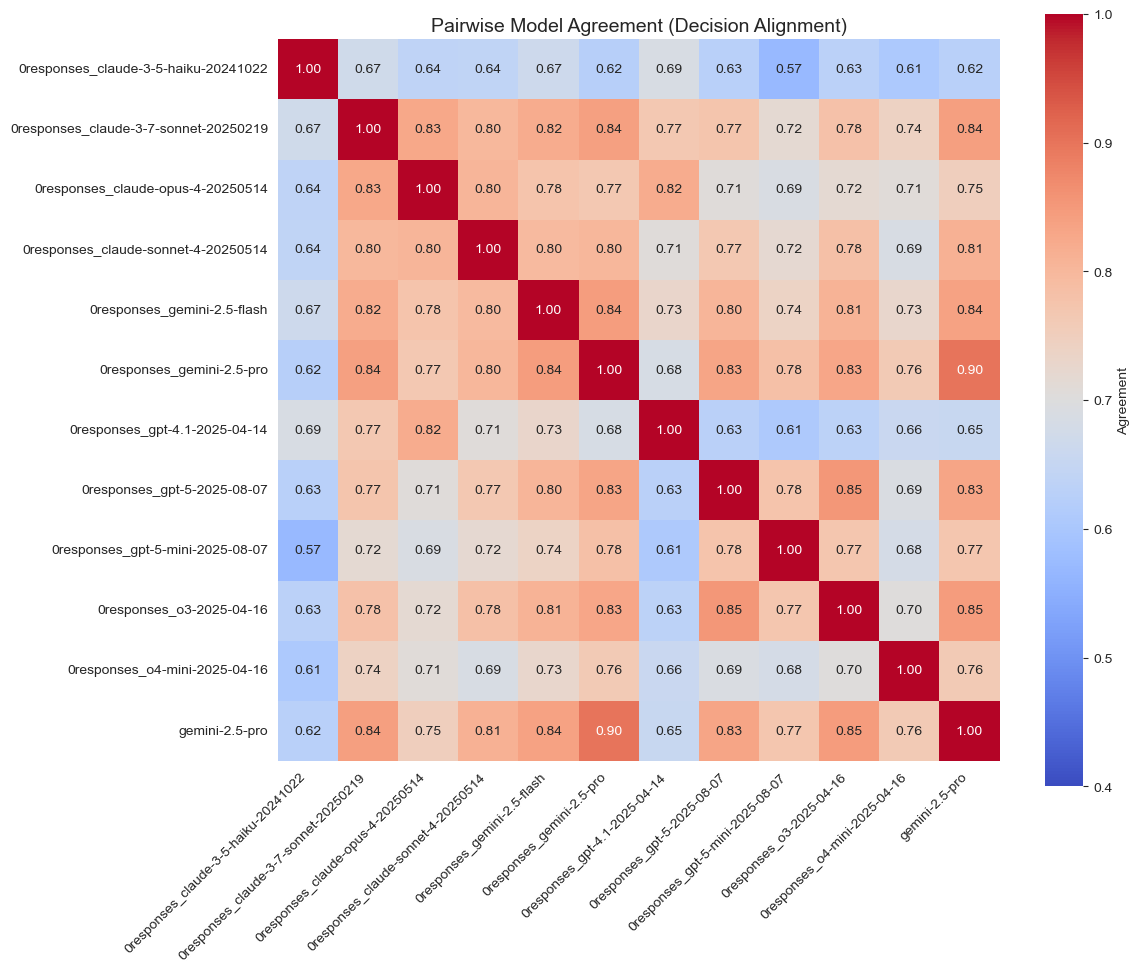

✓ Saved: model-agreement-heatmap.pdf


In [3]:
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    agreement_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0.4,
    vmax=1.0,
    ax=ax,
    square=True,
    cbar_kws={"label": "Agreement"}
)

ax.set_title("Pairwise Model Agreement (Decision Alignment)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(paths.outputs_dir / "model-agreement-heatmap.pdf", bbox_inches="tight")
plt.show()

print("✓ Saved: model-agreement-heatmap.pdf")

## 3. Decision Diversity Metrics

Quantify how much models disagree (ensemble diversity).

In [4]:
def compute_diversity(df, models):
    """Compute average pairwise disagreement (diversity) for each condition."""
    conds = sorted(df['condition'].unique())
    
    rows = []
    for cond in conds:
        dfc = df[df['condition'] == cond]
        
        # Pairwise disagreements for this condition
        disagreements = []
        n_trials = 0
        
        for i, model_i in enumerate(models):
            for j, model_j in enumerate(models):
                if i >= j:
                    continue  # avoid duplicates
                
                df_i = dfc[dfc['participantID'] == model_i].set_index('stimID')['decision']
                df_j = dfc[dfc['participantID'] == model_j].set_index('stimID')['decision']
                
                common = df_i.index.intersection(df_j.index)
                if len(common) > 0:
                    disagreements.append((df_i[common] != df_j[common]).mean())
                    n_trials = len(common)
        
        if disagreements:
            rows.append({
                "condition": cond,
                "mean_disagreement": np.mean(disagreements),
                "std_disagreement": np.std(disagreements),
                "n_unique_pairs": len(disagreements),
                "n_trials": n_trials
            })
    
    return pd.DataFrame(rows)

diversity_df = compute_diversity(model_master, models)
print("Decision Diversity by Condition:")
display(diversity_df)

Decision Diversity by Condition:


,condition,mean_disagreement,std_disagreement,n_unique_pairs,n_trials
0,100_0,0.230712,0.083122,66,1000
1,50_50,0.285061,0.091095,66,1000
2,80_20,0.263636,0.076577,66,1000


## 4. Model Accuracy Ranking

Rank models by overall accuracy across conditions.

Model Ranking by Accuracy:


,model,accuracy,n_trials
11,gemini-2.5-pro,0.860333,3000
5,0responses_gemini-2.5-pro,0.845000,3000
1,0responses_claude-3-7-sonnet-20250219,0.839000,3000
4,0responses_gemini-2.5-flash,0.798333,3000
9,0responses_o3-2025-04-16,0.789667,3000
7,0responses_gpt-5-2025-08-07,0.783000,3000
2,0responses_claude-opus-4-20250514,0.758333,3000
3,0responses_claude-sonnet-4-20250514,0.754667,3000
10,0responses_o4-mini-2025-04-16,0.739000,3000
8,0responses_gpt-5-mini-2025-08-07,0.716000,3000


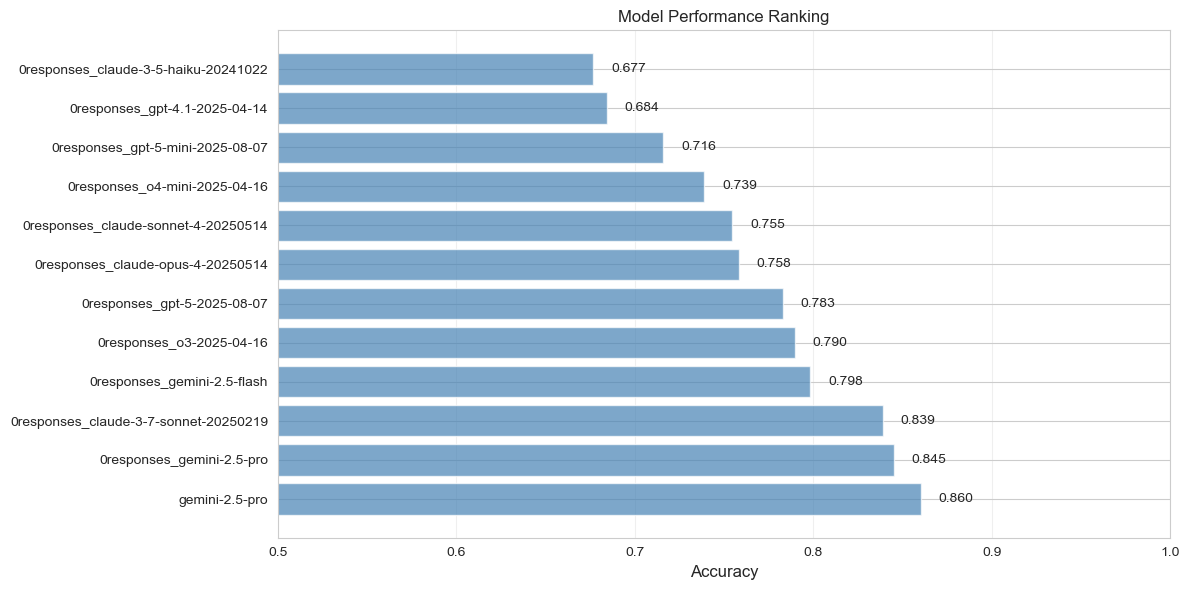

✓ Saved: model-accuracy-ranking.pdf


In [5]:
model_accuracy = []

for model in models:
    mdf = model_master[model_master['participantID'] == model]
    acc = (mdf['decision'] == mdf['TP']).mean()
    n_trials = len(mdf)
    
    model_accuracy.append({
        "model": model,
        "accuracy": acc,
        "n_trials": n_trials
    })

model_rank = pd.DataFrame(model_accuracy).sort_values("accuracy", ascending=False)
print("Model Ranking by Accuracy:")
display(model_rank)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(model_rank["model"], model_rank["accuracy"], color="steelblue", alpha=0.7)
ax.set_xlabel("Accuracy", fontsize=12)
ax.set_title("Model Performance Ranking", fontsize=12)
ax.set_xlim([0.5, 1.0])
ax.grid(axis="x", alpha=0.3)

for i, (model, acc) in enumerate(zip(model_rank["model"], model_rank["accuracy"])):
    ax.text(acc + 0.01, i, f"{acc:.3f}", va="center")

plt.tight_layout()
plt.savefig(paths.outputs_dir / "model-accuracy-ranking.pdf", bbox_inches="tight")
plt.show()

print("✓ Saved: model-accuracy-ranking.pdf")

## 5. Complementarity Analysis

Which models make different types of errors? (Error pattern correlation)

Error Pattern Correlation (high = similar errors, low = complementary):


,0responses_claude-3-5-haiku-20241022,0responses_claude-3-7-sonnet-20250219,0responses_claude-opus-4-20250514,0responses_claude-sonnet-4-20250514,0responses_gemini-2.5-flash,0responses_gemini-2.5-pro,0responses_gpt-4.1-2025-04-14,0responses_gpt-5-2025-08-07,0responses_gpt-5-mini-2025-08-07,0responses_o3-2025-04-16,0responses_o4-mini-2025-04-16,gemini-2.5-pro
0responses_claude-3-5-haiku-20241022,1.000,0.149,0.116,0.124,0.164,0.007,0.280,0.070,-0.015,0.073,0.052,-0.007
0responses_claude-3-7-sonnet-20250219,0.149,1.000,0.486,0.404,0.401,0.396,0.415,0.271,0.217,0.284,0.246,0.378
0responses_claude-opus-4-20250514,0.116,0.486,1.000,0.469,0.359,0.287,0.568,0.168,0.200,0.194,0.225,0.217
0responses_claude-sonnet-4-20250514,0.124,0.404,0.469,1.000,0.416,0.402,0.281,0.348,0.285,0.384,0.174,0.427
0responses_gemini-2.5-flash,0.164,0.401,0.359,0.416,1.000,0.476,0.322,0.409,0.301,0.415,0.237,0.440
0responses_gemini-2.5-pro,0.007,0.396,0.287,0.402,0.476,1.000,0.169,0.456,0.410,0.439,0.303,0.606
0responses_gpt-4.1-2025-04-14,0.280,0.415,0.568,0.281,0.322,0.169,1.000,0.064,0.067,0.070,0.170,0.068
0responses_gpt-5-2025-08-07,0.070,0.271,0.168,0.348,0.409,0.456,0.064,1.000,0.413,0.564,0.153,0.448
0responses_gpt-5-mini-2025-08-07,-0.015,0.217,0.200,0.285,0.301,0.410,0.067,0.413,1.000,0.397,0.191,0.373
0responses_o3-2025-04-16,0.073,0.284,0.194,0.384,0.415,0.439,0.070,0.564,0.397,1.000,0.185,0.483


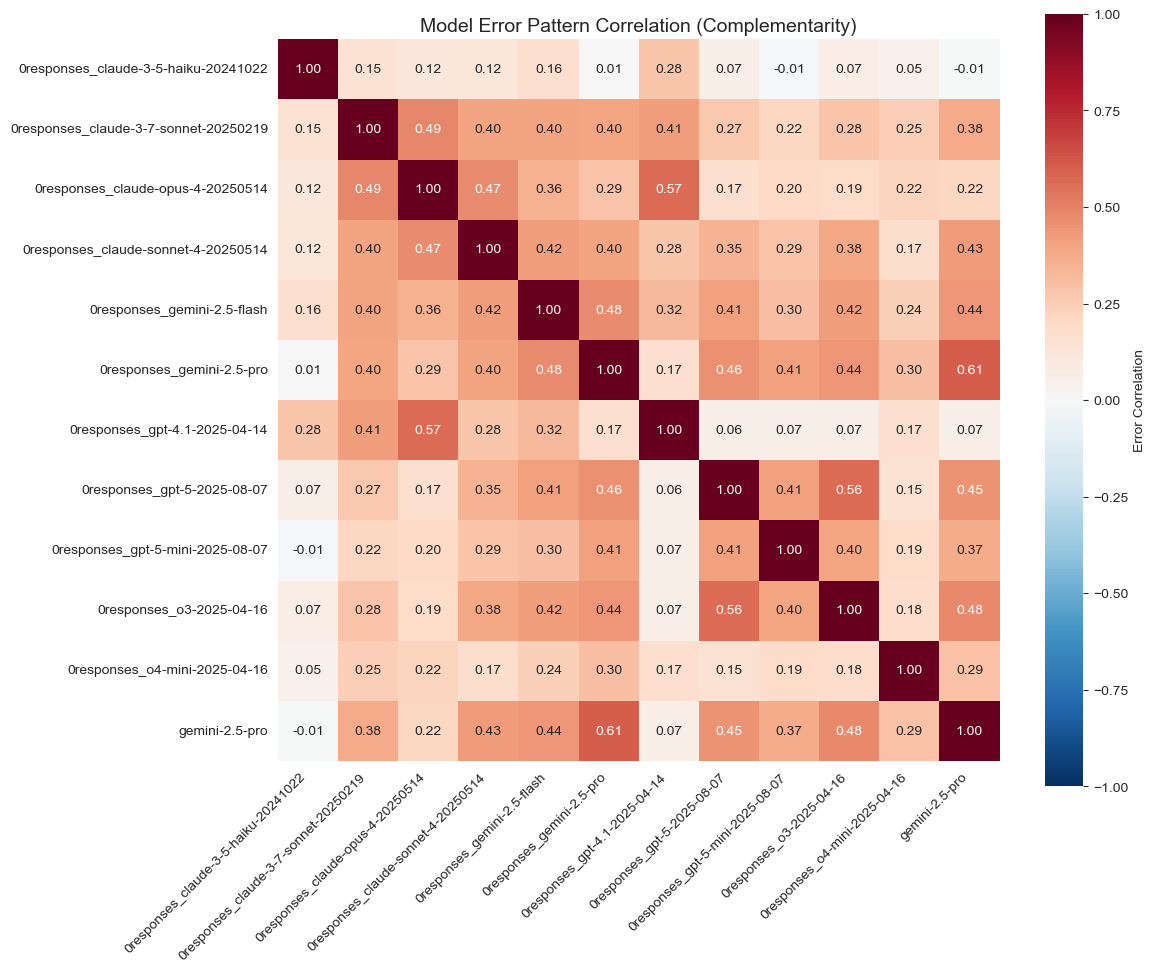

✓ Saved: model-error-correlation.pdf


In [6]:
def compute_error_correlation(df, models):
    """Compute correlation of error patterns between models."""
    # Create error vectors (1 if wrong, 0 if correct)
    error_vectors = {}
    
    for model in models:
        mdf = df[df['participantID'] == model].set_index('stimID')
        error_vectors[model] = (mdf['decision'] != mdf['TP']).astype(int)
    
    # Compute pairwise correlations
    n_models = len(models)
    corr_matrix = np.zeros((n_models, n_models))
    
    for i, model_i in enumerate(models):
        for j, model_j in enumerate(models):
            if i == j:
                corr_matrix[i, j] = 1.0
            else:
                errors_i = error_vectors[model_i]
                errors_j = error_vectors[model_j]
                
                common = errors_i.index.intersection(errors_j.index)
                if len(common) > 1:
                    corr = np.corrcoef(
                        errors_i[common].values,
                        errors_j[common].values
                    )[0, 1]
                    corr_matrix[i, j] = corr if not np.isnan(corr) else 0
    
    return pd.DataFrame(corr_matrix, index=models, columns=models)

error_corr = compute_error_correlation(model_master, models)
print("Error Pattern Correlation (high = similar errors, low = complementary):")
display(error_corr.round(3))

# Visualize
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    error_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    square=True,
    cbar_kws={"label": "Error Correlation"}
)

ax.set_title("Model Error Pattern Correlation (Complementarity)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(paths.outputs_dir / "model-error-correlation.pdf", bbox_inches="tight")
plt.show()

print("✓ Saved: model-error-correlation.pdf")

## 6. Condition-Specific Performance

How does each model perform across conditions?

Model Accuracy by Condition:


condition,50_50,80_20,100_0
model,,,
0responses_claude-3-5-haiku-20241022,0.594,0.720,0.716
0responses_claude-3-7-sonnet-20250219,0.820,0.847,0.850
0responses_claude-opus-4-20250514,0.737,0.737,0.801
0responses_claude-sonnet-4-20250514,0.741,0.757,0.766
0responses_gemini-2.5-flash,0.770,0.794,0.831
0responses_gemini-2.5-pro,0.823,0.822,0.890
0responses_gpt-4.1-2025-04-14,0.671,0.698,0.684
0responses_gpt-5-2025-08-07,0.764,0.746,0.839
0responses_gpt-5-mini-2025-08-07,0.690,0.671,0.787


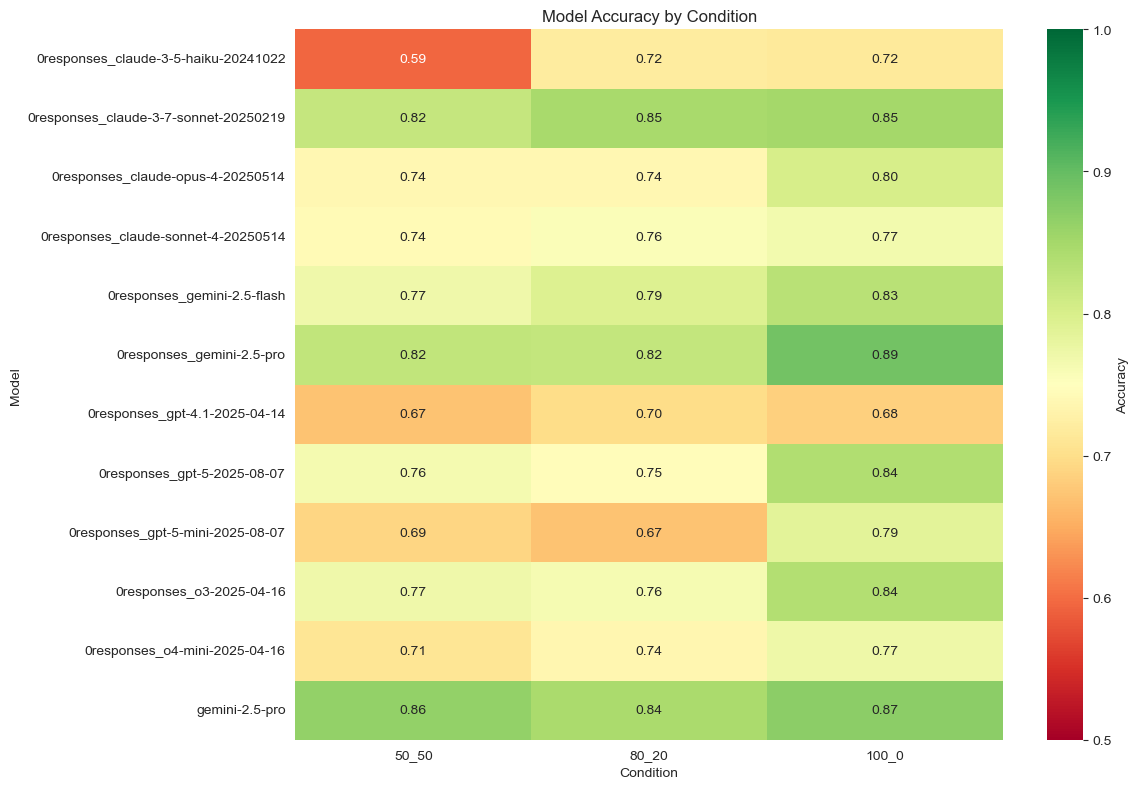

✓ Saved: model-condition-performance.pdf


In [7]:
cond_perf = []

for model in models:
    mdf = model_master[model_master['participantID'] == model]
    
    for cond in sorted(mdf['condition'].unique()):
        cdf = mdf[mdf['condition'] == cond]
        acc = (cdf['decision'] == cdf['TP']).mean()
        
        cond_perf.append({
            "model": model,
            "condition": cond,
            "accuracy": acc
        })

cond_perf_df = pd.DataFrame(cond_perf)
cond_pivot = cond_perf_df.pivot(index="model", columns="condition", values="accuracy")
cond_pivot = cond_pivot[["50_50", "80_20", "100_0"]]

print("Model Accuracy by Condition:")
display(cond_pivot.round(3))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    cond_pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1.0,
    ax=ax,
    cbar_kws={"label": "Accuracy"}
)

ax.set_title("Model Accuracy by Condition", fontsize=12)
ax.set_xlabel("Condition")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(paths.outputs_dir / "model-condition-performance.pdf", bbox_inches="tight")
plt.show()

print("✓ Saved: model-condition-performance.pdf")

## 7. Summary Report

Ensemble composition insights.